## kMeans  

In [1451]:
FARTHERST_INITIALIZATION = 1
USE_WITHIN_CLUSTER_SUM_OF_SQUARES = 0
LOAD_UNBALANCE_DATASET = 1

Load data

In [1452]:
import numpy as np
import pandas as pd

In [ ]:
dataset = "unbalance" if LOAD_UNBALANCE_DATASET else "normal"
separator = " " if LOAD_UNBALANCE_DATASET else "\t"
df = pd.read_csv(f"../inputs/{dataset}.txt", sep=separator, header=None)
print(len(df))

6500


In [1454]:
df_input = df.copy()

<Axes: xlabel='0', ylabel='1'>

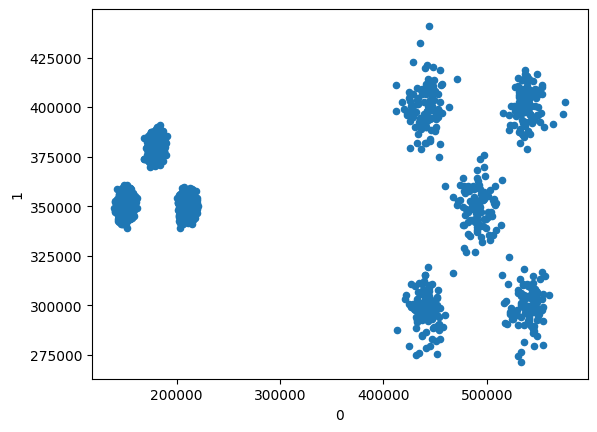

In [1455]:
df.plot.scatter(x=0, y=1)

In [1456]:
def initialize_centroids_random(df, k):
    centroids = df.sample(n=k).copy()[[0, 1]].reset_index(drop=True)
    return centroids

<Axes: xlabel='0', ylabel='1'>

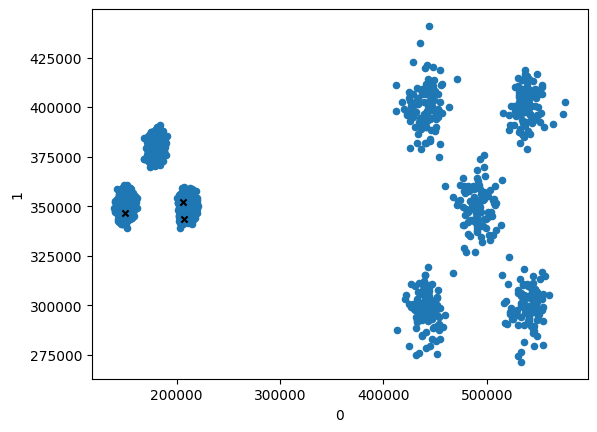

In [1458]:
centroids = initialize_centroids_random(df, k=3)
ax = df.plot.scatter(x=0, y=1)
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [1459]:
def initialize_centroids_furthest(df, k):
    centroids = df.sample(n=1).copy()[[0, 1]].reset_index(drop=True)

    while len(centroids) < k:
        distances = df.apply(
            lambda row: min(np.linalg.norm(row - centroids.iloc[i]) for i in range(len(centroids))), axis=1
        )

        new_centroid = df.iloc[distances.idxmax()]
        centroids = pd.concat([centroids, new_centroid.to_frame().T], ignore_index=True)

    return centroids

In [1460]:
centroids

,0,1
0,205922,352244
1,149955,346655
2,206797,343705


<Axes: xlabel='0', ylabel='1'>

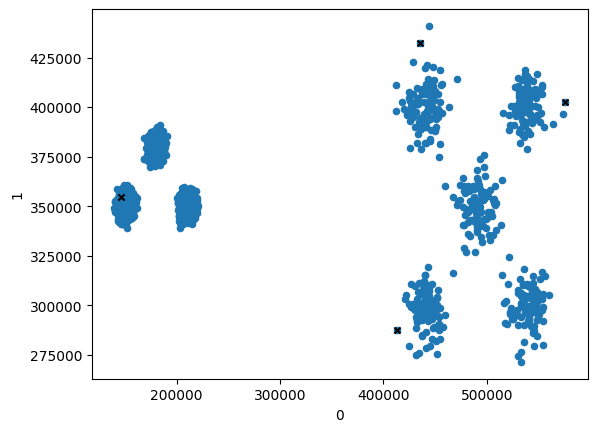

In [ ]:
centroids = initialize_centroids_furthest(df, k=4)
ax = df.plot.scatter(x=0, y=1)
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [1462]:
def find_closest_centroid(df, centroids):
    distances = pd.DataFrame(index=df.index, columns=centroids.index)

    for i in centroids.index:
        distances[i] = np.linalg.norm(df[[0, 1]] - centroids.loc[i], axis=1)

    return distances.idxmin(axis=1)

In [1463]:
closest_centroids = find_closest_centroid(df, centroids)
df["centroids"] = closest_centroids
df

,0,1,centroids
0,151700,351102,0
1,155799,354358,0
2,142857,352716,0
3,152726,349144,0
4,151008,349692,0
...,...,...,...
6495,538990,412773,1
6496,533767,393738,1
6497,546754,394768,1
6498,541605,396515,1


<Axes: xlabel='0', ylabel='1'>

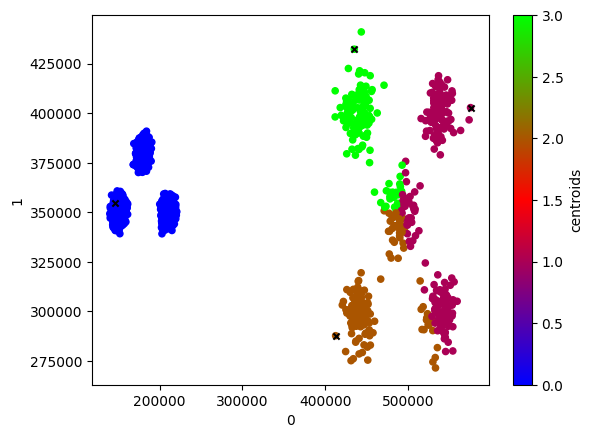

In [1464]:
ax = df.plot.scatter(x=0, y=1, c="centroids", colormap="brg")
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [1465]:
def replace_centroids(df, centroids):
    new_centroids = pd.DataFrame(index=centroids.index, columns=centroids.columns, dtype=np.float64)

    for i in centroids.index:
        new_centroids.loc[i] = df[df["centroids"] == i].mean()

    return new_centroids

In [1466]:
def print_result(df, centroids):
    ax = df.plot.scatter(x=0, y=1, c="centroids", colormap="brg")
    centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

               0              1
0  179969.987167  360025.035500
1  533468.635135  354899.527027
2  460454.536424  307327.516556
3  449291.921260  391240.653543 0    float64
1    float64
dtype: object


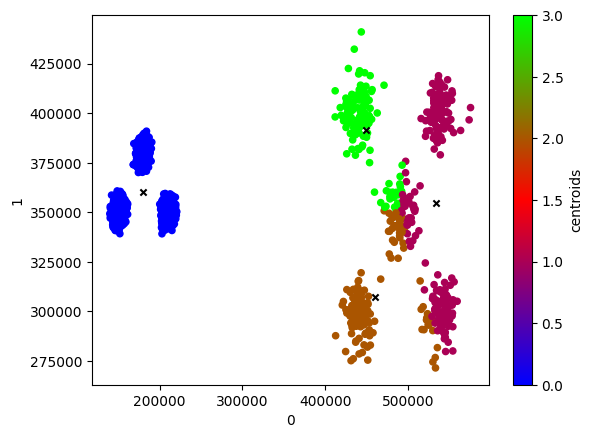

In [1467]:
centroids = replace_centroids(df, centroids)
print(centroids, centroids.dtypes)

print_result(df, centroids)

In [1468]:
def kmeans(df_input, k, max_iterations=500):
    df = df_input.copy()
    initialization_function = initialize_centroids_furthest if FARTHERST_INITIALIZATION else initialize_centroids_random
    centroids = initialization_function(df, k)

    for i in range(max_iterations + 1):
        if i % 100 == 0:
            print(f"Iteration {i}")

        closest_centroids = find_closest_centroid(df, centroids)
        df["centroids"] = closest_centroids

        new_centroids = replace_centroids(df, centroids)

        if centroids.equals(new_centroids):
            break

        centroids = new_centroids

    return df, centroids

Iteration 0


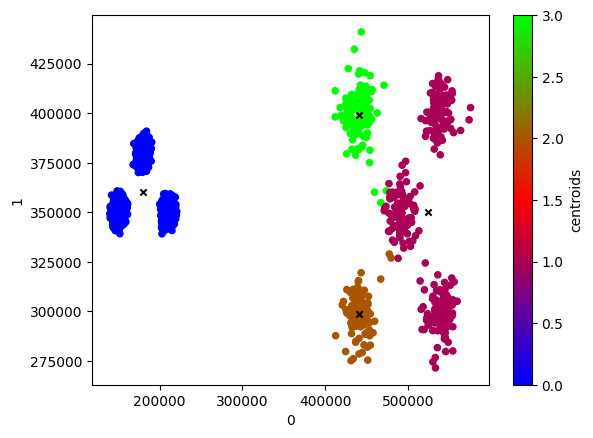

In [1469]:
df, centroids = kmeans(df_input, k=4)
print_result(df, centroids)

In [1470]:
def get_within_cluster_sum_of_squares(df, centroids):
    wcss = 0

    for i in centroids.index:
        cluster_points = df[df["centroids"] == i].iloc[:, :-1]
        centroid = centroids.loc[i].values
        wcss += np.sum(np.linalg.norm(cluster_points - centroid, axis=1) ** 2)

    return wcss

In [1471]:
get_within_cluster_sum_of_squares(df, centroids)

5669584814465.194

In [1472]:
def get_mean_intra_cluster_distance(df, centroids):
    distances = pd.DataFrame(index=centroids.index, columns=["mean_distance"])

    for i in centroids.index:
        cluster_points = df[df["centroids"] == i].iloc[:, :-1]
        centroid = centroids.loc[i].values
        distances.loc[i] = np.mean(np.linalg.norm(cluster_points - centroid, axis=1))

    return distances.mean().astype(np.float64).values[0]

In [1473]:
get_mean_intra_cluster_distance(df, centroids)

25557.193162045536

In [1474]:
def random_restart_knn(df_input, k, max_iterations=500, restarts=3):
    metric_function = (
        get_within_cluster_sum_of_squares if USE_WITHIN_CLUSTER_SUM_OF_SQUARES else get_mean_intra_cluster_distance
    )

    best_metric = float("inf")
    best_df = None
    best_centroids = None

    for i in range(restarts):
        df, centroids = kmeans(df_input, k, max_iterations)
        current_metric = metric_function(df, centroids)

        print(current_metric, best_metric)
        if current_metric < best_metric:
            best_metric = current_metric
            best_df = df
            best_centroids = centroids

    return best_df, best_centroids

Iteration 0
9144.441783994942 inf
Iteration 0
11872.837670398565 9144.441783994942
Iteration 0
13224.389749227088 9144.441783994942


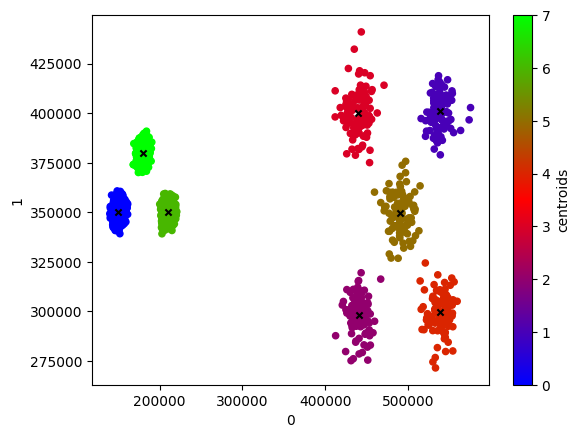

In [1475]:
best_df, best_centroids = random_restart_knn(df_input, k=8, restarts=3)
print_result(best_df, best_centroids)

In [1476]:
def elbow_method(df_input, k_max=10, max_iterations=500, restarts=3):
    metric_function = (
        get_within_cluster_sum_of_squares if USE_WITHIN_CLUSTER_SUM_OF_SQUARES else get_mean_intra_cluster_distance
    )

    metric_values = []

    for k in range(2, k_max + 1):
        print(f"\nCalculating for k={k}")
        df_best, best_centroids = random_restart_knn(df_input, k, max_iterations, restarts=restarts)
        metric_values.append((k, metric_function(df_best, best_centroids)))

    return metric_values

In [1478]:
metric_values = elbow_method(df_input)
metric_values


Calculating for k=2
Iteration 0
43804.202030734705 inf
Iteration 0
43804.202030734705 43804.202030734705
Iteration 0
43804.202030734705 43804.202030734705

Calculating for k=3
Iteration 0
31639.59446905002 inf
Iteration 0
41823.901369241095 31639.59446905002
Iteration 0
41823.901369241095 31639.59446905002

Calculating for k=4
Iteration 0
25557.193162045536 inf
Iteration 0
25557.193162045536 25557.193162045536
Iteration 0
25557.193162045536 25557.193162045536

Calculating for k=5
Iteration 0
21016.8944428681 inf
Iteration 0
21016.8944428681 21016.8944428681
Iteration 0
21016.8944428681 21016.8944428681

Calculating for k=6
Iteration 0
14889.041546040158 inf
Iteration 0
14889.041546040158 14889.041546040158
Iteration 0
14889.041546040158 14889.041546040158

Calculating for k=7
Iteration 0
12378.042179847582 inf
Iteration 0
12409.245379455488 12378.042179847582
Iteration 0
12378.042179847582 12378.042179847582

Calculating for k=8
Iteration 0
11845.534870741647 inf
Iteration 0
11845.534

[(2, 43804.202030734705),
 (3, 31639.59446905002),
 (4, 25557.193162045536),
 (5, 21016.8944428681),
 (6, 14889.041546040158),
 (7, 12378.042179847582),
 (8, 11845.534870741647),
 (9, 11456.351552945423),
 (10, 8961.640298953527)]

We can see that the best value is somewhere around k=4 or k=5 for the normal and 8 for the unbalanced

    k        metric
0   2  43804.202031
1   3  31639.594469
2   4  25557.193162
3   5  21016.894443
4   6  14889.041546
5   7  12378.042180
6   8  11845.534871
7   9  11456.351553
8  10   8961.640299


<Axes: xlabel='k'>

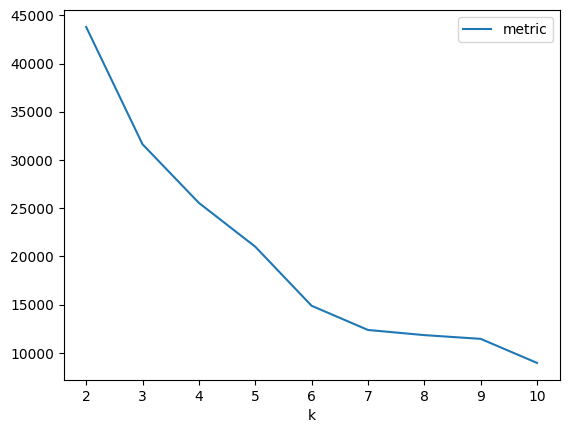

In [1479]:
df_metric_values = pd.DataFrame(metric_values, columns=["k", "metric"])
print(df_metric_values)
df_metric_values.plot(x="k", y="metric", kind="line")

Iteration 0
11872.837670398565 inf
Iteration 0
11845.534870741647 11872.837670398565
Iteration 0
11872.837670398565 11845.534870741647
Iteration 0
11845.534870741647 11845.534870741647
Iteration 0
9144.441783994942 11845.534870741647
Iteration 0
11872.837670398565 9144.441783994942
Iteration 0
11845.534870741647 9144.441783994942
Iteration 0
11857.548953558615 9144.441783994942
Iteration 0
11872.837670398565 9144.441783994942
Iteration 0
9144.441783994942 9144.441783994942


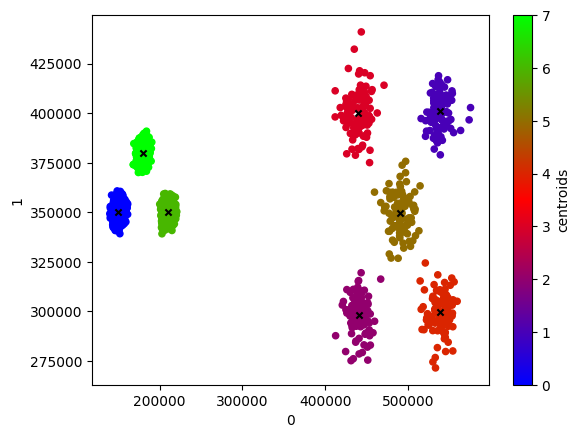

In [1480]:
best_df, best_centroids = random_restart_knn(df_input, k=8, restarts=10)
print_result(best_df, best_centroids)